In [67]:
# Credit Risk Score Modeling
## 1. Data Loading and Preprocessing

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [15]:
columns = [
   "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

df = pd.read_csv("data/german.data",
                 sep = r"\s+",
                 header = None, 
                 names = columns)
df.head(10)

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
5,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1
6,A14,24,A32,A42,2835,A63,A75,3,A93,A101,...,A122,53,A143,A152,1,A173,1,A191,A201,1
7,A12,36,A32,A41,6948,A61,A73,2,A93,A101,...,A123,35,A143,A151,1,A174,1,A192,A201,1
8,A14,12,A32,A43,3059,A64,A74,2,A91,A101,...,A121,61,A143,A152,1,A172,1,A191,A201,1
9,A12,30,A34,A40,5234,A61,A71,4,A94,A101,...,A123,28,A143,A152,2,A174,1,A191,A201,2


In [16]:
# Inspect and clean the data
df.shape

(1000, 21)

In [17]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_status          1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment               1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [21]:
df["credit_risk"].value_counts()

credit_risk
1    700
2    300
Name: count, dtype: int64

In [22]:
df["default"] = df["credit_risk"].map({
    1: 0,
    2: 1
})
df[["credit_risk", "default"]].head(10)
df["default"].value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [ ]:
## 2. Exploratory Data Analysis (EDA)

## 3. Credit Amount vs. Default Risk

df.groupby("default")["credit_amount"].mean()

default
0    2985.457143
1    3938.126667
Name: credit_amount, dtype: float64

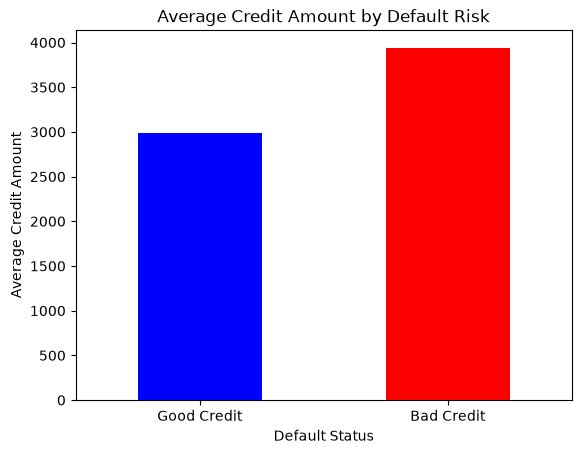

In [31]:
avg_credit = df.groupby("default")["credit_amount"].mean()

avg_credit.plot(kind="bar", color=["blue", "red"])

plt.title("Average Credit Amount by Default Risk")
plt.xlabel("Default Status")
plt.ylabel("Average Credit Amount")
plt.xticks([0, 1], ["Good Credit", "Bad Credit"], rotation=0)

plt.show()

In [32]:
df.groupby("default")["duration"].mean()

default
0    19.207143
1    24.860000
Name: duration, dtype: float64

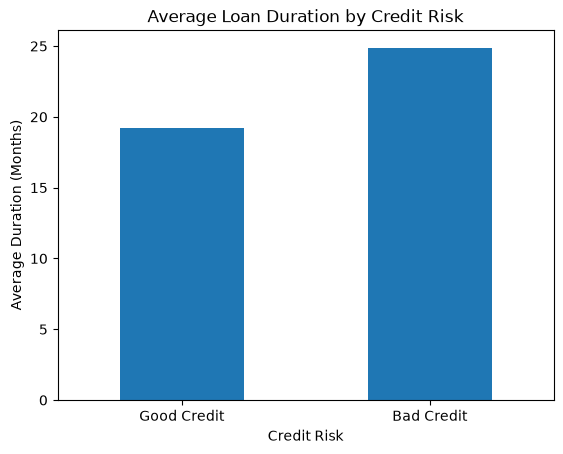

In [33]:
avg_duration = df.groupby("default")["duration"].mean()

avg_duration.plot(kind="bar")

plt.title("Average Loan Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Average Duration (Months)")
plt.xticks([0, 1], ["Good Credit", "Bad Credit"], rotation=0)

plt.show()

In [34]:
df.groupby("default")["age"].mean()

default
0    36.224286
1    33.963333
Name: age, dtype: float64

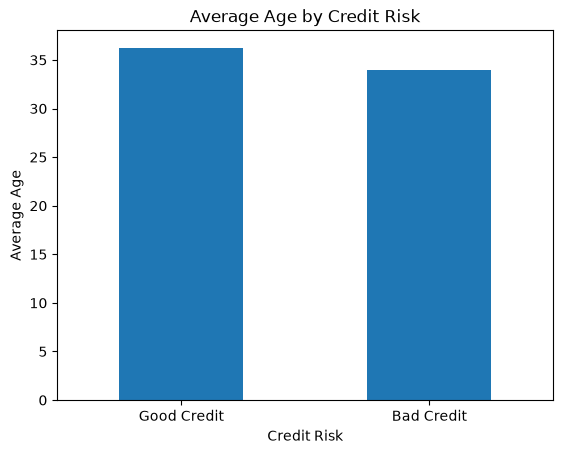

In [35]:
avg_age = df.groupby("default")["age"].mean()

avg_age.plot(kind="bar")

plt.title("Average Age by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Average Age")
plt.xticks([0, 1], ["Good Credit", "Bad Credit"], rotation=0)

plt.show()

In [36]:
#4 — Checking Account Status vs Credit Risk

df["checking_status"].value_counts()

checking_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

In [37]:
df.groupby("checking_status")["default"].mean()

checking_status
A11    0.492701
A12    0.390335
A13    0.222222
A14    0.116751
Name: default, dtype: float64

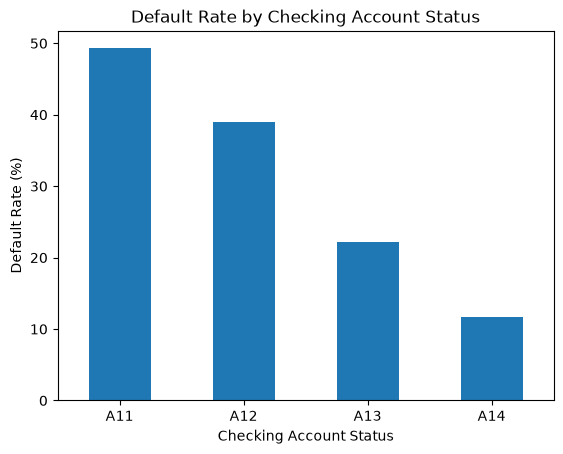

In [38]:
default_by_checking = (
    df.groupby("checking_status")["default"].mean() * 100
)

default_by_checking.plot(kind="bar")

plt.title("Default Rate by Checking Account Status")
plt.xlabel("Checking Account Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# 5. Savings vs Credit Risk

In [39]:
df["savings"].value_counts()

savings
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

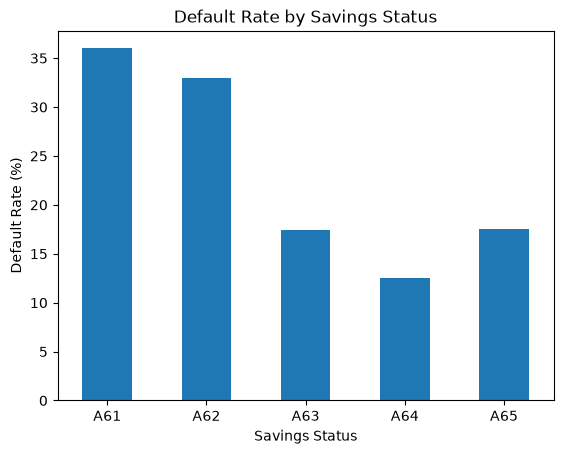

In [40]:
default_by_savings = (
    df.groupby("savings")["default"].mean() * 100
)

default_by_savings.plot(kind="bar")

plt.title("Default Rate by Savings Status")
plt.xlabel("Savings Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# 6. Credit History

In [41]:
df["credit_history"].value_counts()

credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

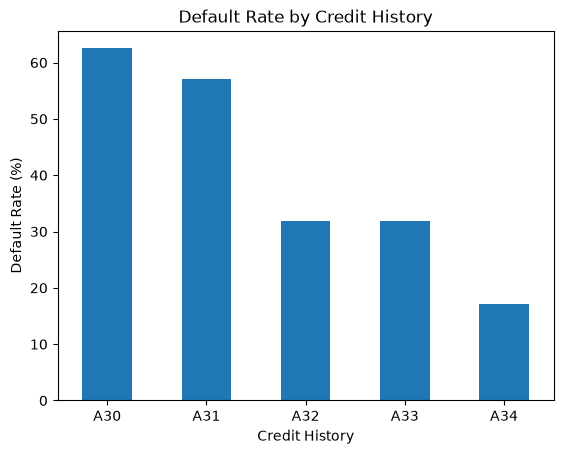

In [42]:
default_by_history = (
    df.groupby("credit_history")["default"].mean() * 100
)

default_by_history.plot(kind="bar")

plt.title("Default Rate by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [46]:
X = df.drop(columns=["credit_risk", "default"])
y = df["default"]

In [47]:
X.shape

(1000, 20)

In [48]:
y.shape

(1000,)

In [49]:
y.value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [ ]:
## Train/Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 20)
X_test: (200, 20)
y_train: (800,)
y_test: (200,)


In [53]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

default
0    0.7
1    0.3
Name: proportion, dtype: float64
default
0    0.7
1    0.3
Name: proportion, dtype: float64


In [55]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X_train.select_dtypes(include=["str", "object"]).columns

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['duration', 'credit_amount', 'installment_rate', 'residence_since',
       'age', 'existing_credits', 'dependents'],
      dtype='str')

Categorical features:
Index(['checking_status', 'credit_history', 'purpose', 'savings', 'employment',
       'personal_status_sex', 'other_debtors', 'property',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'foreign_worker'],
      dtype='str')


In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [62]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [63]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'dependents', 'telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [66]:
y_pred = model.predict(X_test)
y_pred[:10]

print("Predicted:", y_pred[:10])
print("Actual:   ", y_test.iloc[:10].values)

Predicted: [0 0 1 0 0 0 0 0 0 0]
Actual:    [0 0 1 0 1 0 0 0 0 0]


In [68]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.78


In [69]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[124,  16],
       [ 28,  32]])

In [70]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6666666666666666
Recall: 0.5333333333333333
F1 Score: 0.5925925925925926


In [74]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8040476190476191


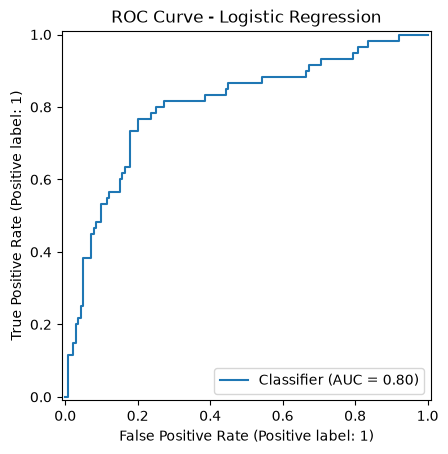

In [75]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [77]:
y_pred_40 = (y_prob >= 0.40).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred_40))
print("Precision:", precision_score(y_test, y_pred_40))
print("Recall:", recall_score(y_test, y_pred_40))
print("F1:", f1_score(y_test, y_pred_40))

Accuracy: 0.79
Precision: 0.6323529411764706
Recall: 0.7166666666666667
F1: 0.671875


In [78]:
confusion_matrix(y_test, y_pred_40)

array([[115,  25],
       [ 17,  43]])

In [79]:
y_pred_30 = (y_prob >= 0.30).astype(int)

print("Threshold = 0.30")
print("Accuracy:", accuracy_score(y_test, y_pred_30))
print("Precision:", precision_score(y_test, y_pred_30))
print("Recall:", recall_score(y_test, y_pred_30))
print("F1:", f1_score(y_test, y_pred_30))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_30))

Threshold = 0.30
Accuracy: 0.755
Precision: 0.5632183908045977
Recall: 0.8166666666666667
F1: 0.6666666666666666

Confusion Matrix:
[[102  38]
 [ 11  49]]


In [81]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(
    "coefficient",
    ascending=False
)

coef_df

,feature,coefficient
23,cat__purpose_A46,0.901684
46,cat__property_A124,0.713710
7,cat__checking_status_A11,0.657834
26,cat__savings_A61,0.640212
59,cat__foreign_worker_A201,0.567781
...,...,...
52,cat__housing_A153,-0.611037
29,cat__savings_A64,-0.628173
17,cat__purpose_A41,-0.714820
15,cat__credit_history_A34,-0.800579
